In [1]:
import torch
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
import sys
from models import LCSONet
ROOT = os.getcwd()
sys.path.insert(0, os.path.join(ROOT, "tests"))
sys.path.insert(0, ROOT)


In [2]:
from trainer import train_hits_classifier
from models import LCSONet
import utils

In [3]:
DEVICE = torch.device("cuda:2")
OUT   = "outputs/"

In [4]:
h5_path = os.path.join('outputs', 'training_data.h5')
with h5py.File(h5_path, 'r') as h5f:
        phis_ds = h5f['phis']
        muons_ds = h5f['muons']
        hits_ds = h5f['hits']
        phis_training = (phis_ds[:])
        muons_training = (muons_ds[:])
        hits_training = (hits_ds[:])
        print(f"Loaded phis {phis_training.shape}, muons {muons_training.shape}, hits {hits_training.shape} from {h5_path}")
muons_0 = muons_training[0,...].reshape(1, muons_training.shape[1], muons_training.shape[2])
labels_0 = hits_training[0,...].reshape(1, hits_training.shape[1])
phi_0 = phis_training[0,...].reshape(1, phis_training.shape[-1])
phi_dim = phi_0.shape[-1]

Loaded phis (513, 43), muons (513, 5000000, 7), hits (513, 5000000) from outputs/training_data.h5


In [5]:
h5_path = os.path.join('outputs', 'test_data.h5')
with h5py.File(h5_path, 'r') as h5f:
    phis_ds = h5f['phis']
    muons_ds = h5f['muons']
    hits_ds = h5f['hits']
    phis_test = (phis_ds[:])
    muons_test = (muons_ds[:])
    hits_test = (hits_ds[:])
    print(f"Loaded phis {phis_test.shape}, muons {muons_test.shape}, hits {hits_test.shape} from {h5_path}")

phi_test_0 = phis_test[0:1]
muons_test_0 = muons_test[0:1]
hits_test_0 = hits_test[0:1].flatten()

#muons = np.load(os.path.join(OUT, "muons.npy"))
#labels = np.load(os.path.join(OUT, "hits.npy"))
#phis = np.load(os.path.join(OUT, "phis.npy"))

Loaded phis (65, 43), muons (65, 50000000, 7), hits (65, 50000000) from outputs/test_data.h5


In [6]:
i = hits_training.sum(-1).argmax()
phi_i = phis_training[i,...].reshape(1, phis_training.shape[-1])
muons_i = muons_training[i,...].reshape(1, muons_training.shape[1], muons_training.shape[2])
labels_i = hits_training[i,...].reshape(1, hits_training.shape[1])

i = hits_test.sum(-1).argmax()
phi_test_i = phis_test[i,...].reshape(1, phis_test.shape[-1])
muons_test_i = muons_test[i,...].reshape(1, muons_test.shape[1], muons_test.shape[2])
hits_test_i = hits_test[i,...].reshape(1, hits_test.shape[1])

In [7]:
model = LCSONet(hidden=8, p=4, phi_dim=phi_dim, x_dim=7, sampling = 'normal', phi_0 = phi_0).to(DEVICE)
lb = model.lower_bound
ub = model.upper_bound

In [8]:
EPOCHS = 30
LR = 1e-3
BATCH_SIZE = int(2**22)

In [9]:
sub = muons_training[..., :6]
muon_mean = sub.mean(axis=(0, 1), dtype=np.float64)
muon_std = sub.std(axis=(0, 1), dtype=np.float64) + 1e-12
model.set_muon_norm(muon_mean, muon_std)
print("muon normalization set on the model:", muon_mean.round(4))

muon normalization set on the model: [ 0.      0.     48.6154  0.      0.     -1.    ]


In [10]:
losses,_ = train_hits_classifier(model, torch.from_numpy(phis_training), 
                               torch.from_numpy(muons_training),
                               torch.from_numpy(hits_training),
                                epochs=EPOCHS, lr=LR,
                               batch_size=BATCH_SIZE, device=DEVICE,
                               scheduler="cosine")

100%|██████████| 30/30 [13:09<00:00, 26.31s/it]


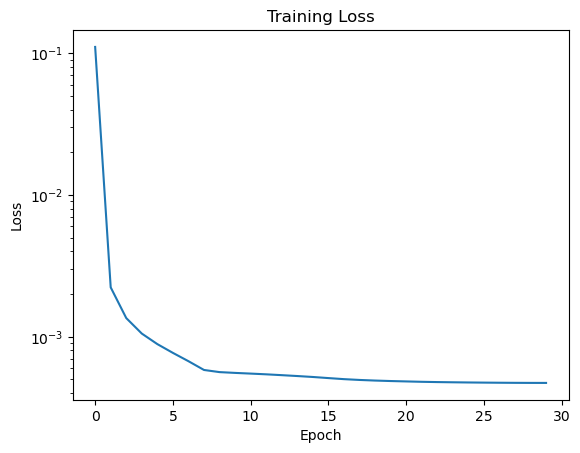

In [11]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.yscale("log")
plt.show()

In [12]:
def model_predict_batches(model, phis, muons, batch_size=BATCH_SIZE, device=DEVICE):
    """Generate model predictions in muon batches to avoid OOM."""
    model.eval()
    outputs = []

    phis_batch = torch.from_numpy(phis).float().to(device)
    n_muons = muons.shape[1]

    with torch.no_grad():
        for i in range(0, n_muons, batch_size):
            end_idx = min(i + batch_size, n_muons)
            muons_batch = torch.from_numpy(muons[:, i:end_idx]).float().to(device)
            output = model(phis_batch, muons_batch)
            outputs.append(output.cpu())

            del muons_batch

    return torch.cat(outputs, dim=1)

# Usage
predictions_uniform = model_predict_batches(model, phi_0, muons_0).sigmoid().cpu().numpy().flatten()
predictions = model_predict_batches(model, phi_test_0, muons_test_0).sigmoid().cpu().numpy().flatten()


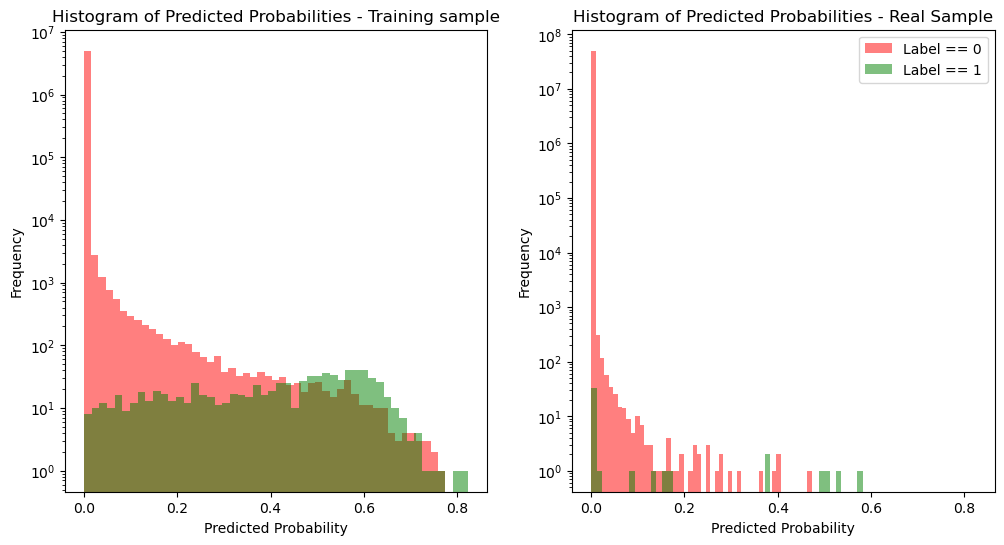

In [13]:
labels_uniform = labels_0.flatten()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharex=True)

ax1.hist(predictions_uniform[labels_uniform == 0], bins=50, color='red', alpha=0.5, label='Label == 0')
ax1.hist(predictions_uniform[labels_uniform == 1], bins=50, color='green', alpha=0.5, label='Label == 1')
ax1.set_xlabel("Predicted Probability")
ax1.set_ylabel("Frequency")
ax1.set_title("Histogram of Predicted Probabilities - Training sample")
ax1.set_yscale("log")
ax2.hist(predictions[hits_test_0 == 0], bins=50, color='red', alpha=0.5, label='Label == 0')
ax2.hist(predictions[hits_test_0 == 1], bins=50, color='green', alpha=0.5, label='Label == 1')
ax2.set_xlabel("Predicted Probability")
ax2.set_ylabel("Frequency")
ax2.set_title("Histogram of Predicted Probabilities - Real Sample")
ax2.set_yscale("log")
plt.legend()
plt.show()

In [14]:
px,py,pz = muons_0[:, :, 0], muons_0[:, :, 1], muons_0[:, :, 2]
pt_uniform = np.sqrt(px**2 + py**2).flatten()
pz_uniform = pz.flatten()

px,py,pz = muons_test[0, :, 0], muons_test[0, :, 1], muons_test[0, :, 2]
pt = np.sqrt(px**2 + py**2).flatten()
pz = pz.flatten()
del px, py

In [15]:
from matplotlib.colors import LogNorm

def compare_2d_histograms(pz, pt, hits, probs, log_scale=True):
    """Three-panel 2D Pz-Pt plots: density, empirical hit probability, and model-predicted probability."""
    pz    = np.asarray(pz).ravel()
    pt    = np.asarray(pt).ravel()
    hits  = np.asarray(hits).ravel()
    probs = np.asarray(probs).ravel()
    
    pz_bins = np.linspace(0, 400, 201)
    pt_bins = np.linspace(0, 13, 201)
    
    # --- First plot: 2D density histogram ---
    H_density, _, _ = np.histogram2d(pz, pt, bins=[pz_bins, pt_bins], density=False)
    
    # --- Second plot: empirical hit probability per bin ---
    H_count, _, _ = np.histogram2d(pz, pt, bins=[pz_bins, pt_bins])
    H_hits, _, _  = np.histogram2d(pz, pt, bins=[pz_bins, pt_bins], weights=hits)
    H_prob = np.divide(H_hits, H_count, out=np.zeros_like(H_hits, dtype=float), where=H_count > 0)
    
    # --- Third plot: model-predicted probability per bin ---
    H_probs_sum, _, _ = np.histogram2d(pz, pt, bins=[pz_bins, pt_bins], weights=probs)
    H_prob_pred = np.divide(H_probs_sum, H_count, out=np.zeros_like(H_probs_sum, dtype=float), where=H_count > 0)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
    
    # Plot 1: Density (log scale)
    pos_vals = H_density[H_density > 0]
    norm_density = LogNorm(vmin=pos_vals.min(), vmax=pos_vals.max()) if len(pos_vals) else LogNorm(vmin=1e-10, vmax=1)
    
    im1 = axes[0].pcolormesh(pz_bins, pt_bins, H_density.T, cmap='viridis', norm=norm_density)
    axes[0].set_xlim(0, 380)
    axes[0].set_ylim(0, 5)
    axes[0].set_xlabel('$P_z$ [GeV]', fontsize=14)
    axes[0].set_ylabel('$P_t$ [GeV]', fontsize=14)
    axes[0].set_title('Density', fontsize=14)
    fig.colorbar(im1, ax=axes[0], label='Density')
    
    # Plot 2: Empirical Hit Probability (log scale)
    H_prob_masked = np.ma.masked_where(H_count == 0, H_prob)
    cmap_prob = plt.cm.viridis.copy()
    cmap_prob.set_bad('white')
    if log_scale:
        norm_prob = LogNorm(vmin=1e-9, vmax=1.0)
    else:
        norm_prob = None
    
    im2 = axes[1].pcolormesh(pz_bins, pt_bins, H_prob_masked.T, cmap=cmap_prob, norm=norm_prob)
    axes[1].set_xlim(0, 380)
    axes[1].set_ylim(0, 5)
    axes[1].set_xlabel('$P_z$ [GeV]', fontsize=14)
    axes[1].set_ylabel('$P_t$ [GeV]', fontsize=14)
    axes[1].set_title('Hit Probability', fontsize=14)
    
    # Plot 3: Predicted Probability (log scale)
    H_prob_pred_masked = np.ma.masked_where(H_count == 0, H_prob_pred)
    cmap_pred = plt.cm.viridis.copy()
    cmap_pred.set_bad('white')
    
    im3 = axes[2].pcolormesh(pz_bins, pt_bins, H_prob_pred_masked.T, cmap=cmap_pred, norm=norm_prob)
    axes[2].set_xlim(0, 380)
    axes[2].set_ylim(0, 5)
    axes[2].set_xlabel('$P_z$ [GeV]', fontsize=14)
    axes[2].set_title('Predicted Probability', fontsize=14)
    fig.colorbar(im3, ax=axes[1:3], label='Probability')
    return fig, axes

def plot_calibration(probs, hits, n_bins=10, figsize=(8, 6)):
    """
    Plots a calibration (reliability) diagram.
    
    Parameters
    ----------
    probs : array-like
        Predicted probabilities (0 to 1).
    hits : array-like
        True binary labels (0 or 1).
    n_bins : int
        Number of equal-width bins for predicted probabilities.
    figsize : tuple
        Figure size.
        
    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """
    probs = np.asarray(probs).ravel()
    hits  = np.asarray(hits).ravel()
    
    # Equal-width bins in [0, 1]
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width = 1.0 / n_bins
    
    mean_predicted = np.empty(n_bins)
    fraction_positive = np.empty(n_bins)
    counts = np.empty(n_bins)
    
    for i in range(n_bins):
        mask = (probs >= bin_edges[i]) & (probs < bin_edges[i + 1])
        # Include right edge for the last bin
        if i == n_bins - 1:
            mask = (probs >= bin_edges[i]) & (probs <= bin_edges[i + 1])
        
        counts[i] = mask.sum()
        if counts[i] > 0:
            mean_predicted[i] = probs[mask].mean()
            fraction_positive[i] = hits[mask].mean()
        else:
            mean_predicted[i] = bin_centers[i]
            fraction_positive[i] = np.nan
    
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    
    # Perfect calibration diagonal
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfectly calibrated')
    
    # Calibration curve
    valid = ~np.isnan(fraction_positive)
    ax.plot(mean_predicted[valid], fraction_positive[valid], 'o-', 
            color='steelblue', lw=2, markersize=8, label='Model')
    
    # Counts histogram on twin axis (log scale)
    ax2 = ax.twinx()
    ax2.bar(bin_centers, counts, width=bin_width * 0.8, alpha=0.25, 
            color='gray', edgecolor='none', label='Count')
    ax2.set_yscale('log')
    ax2.set_ylabel('Number of samples', fontsize=12, color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Mean predicted probability', fontsize=14)
    ax.set_ylabel('Fraction of positives (hits)', fontsize=14)
    ax.set_title('Calibration Plot', fontsize=14)
    ax.legend(loc='upper left')
    
    return fig, ax

def plot_hit_scatter(pz, pt, hits, weights=None, s=5, figsize=(6, 5),
                      weight_range=(0.09, 700), cmap_name='YlOrRd', alpha_range=(0.15, 1.0)):
    """Scatter plot of Pz-Pt for muons that produced a hit.

    If `weights` is given, points are colored on a soft-yellow -> dark-red scale
    (log scale over `weight_range`) that also gets more opaque as weight increases.
    Without weights, all hits are drawn in a single flat color.
    """
    pz = np.asarray(pz).ravel()
    pt = np.asarray(pt).ravel()
    hits = np.asarray(hits).ravel().astype(bool)

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    if weights is None:
        ax.scatter(pz[hits], pt[hits], s=s, alpha=0.5, edgecolors='none', color='steelblue')
    else:
        weights = np.asarray(weights).ravel()[hits]
        pz_hits, pt_hits = pz[hits], pt[hits]

        order = np.argsort(weights)  # low-weight (faint) points drawn first, dark ones on top
        pz_hits, pt_hits, weights = pz_hits[order], pt_hits[order], weights[order]

        norm = LogNorm(vmin=weight_range[0], vmax=weight_range[1], clip=True)
        weight_frac = norm(weights)
        colors = plt.get_cmap(cmap_name)(weight_frac)
        colors[:, 3] = alpha_range[0] + (alpha_range[1] - alpha_range[0]) * weight_frac

        ax.scatter(pz_hits, pt_hits, s=s, edgecolors='none', color=colors)

        sm = plt.cm.ScalarMappable(cmap=cmap_name, norm=norm)
        sm.set_array([])
        fig.colorbar(sm, ax=ax, label='Weight')

    ax.set_xlim(0, 380)
    ax.set_ylim(0, 5)
    ax.set_xlabel('$P_z$ [GeV]', fontsize=14)
    ax.set_ylabel('$P_t$ [GeV]', fontsize=14)
    ax.set_title('Muon Hits', fontsize=14)

    return fig, ax

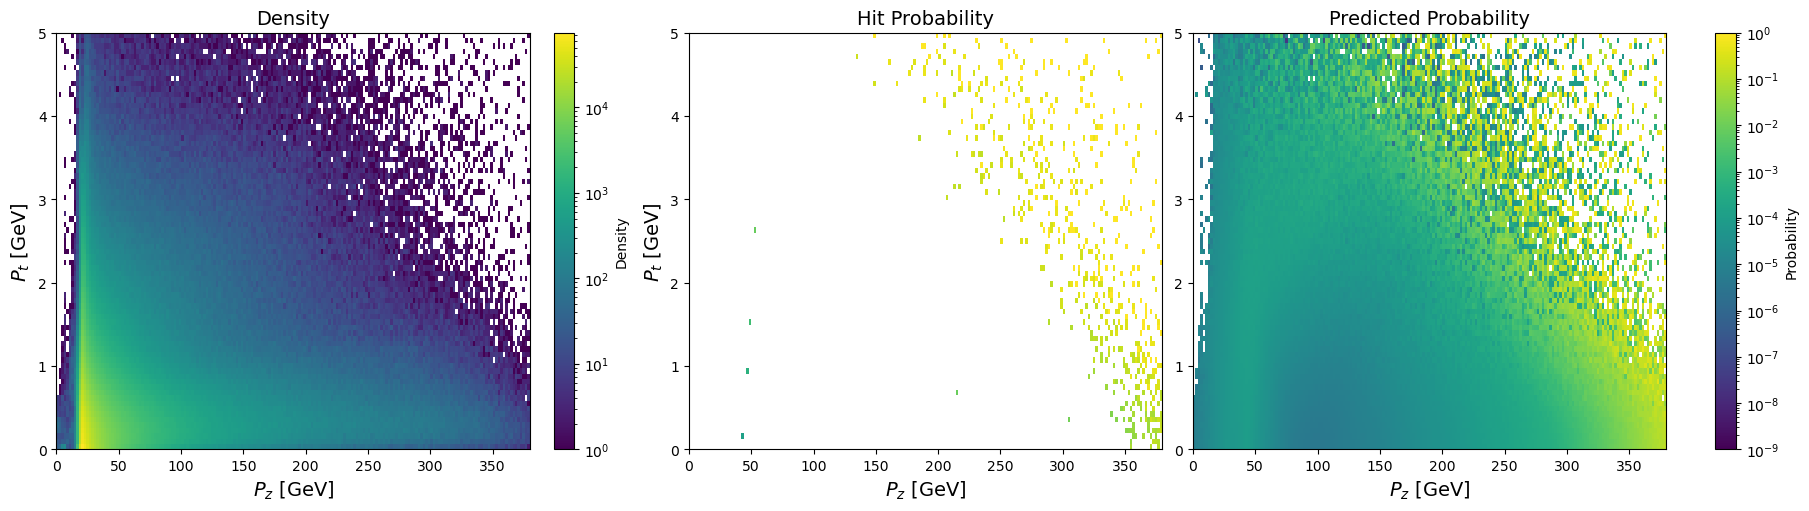

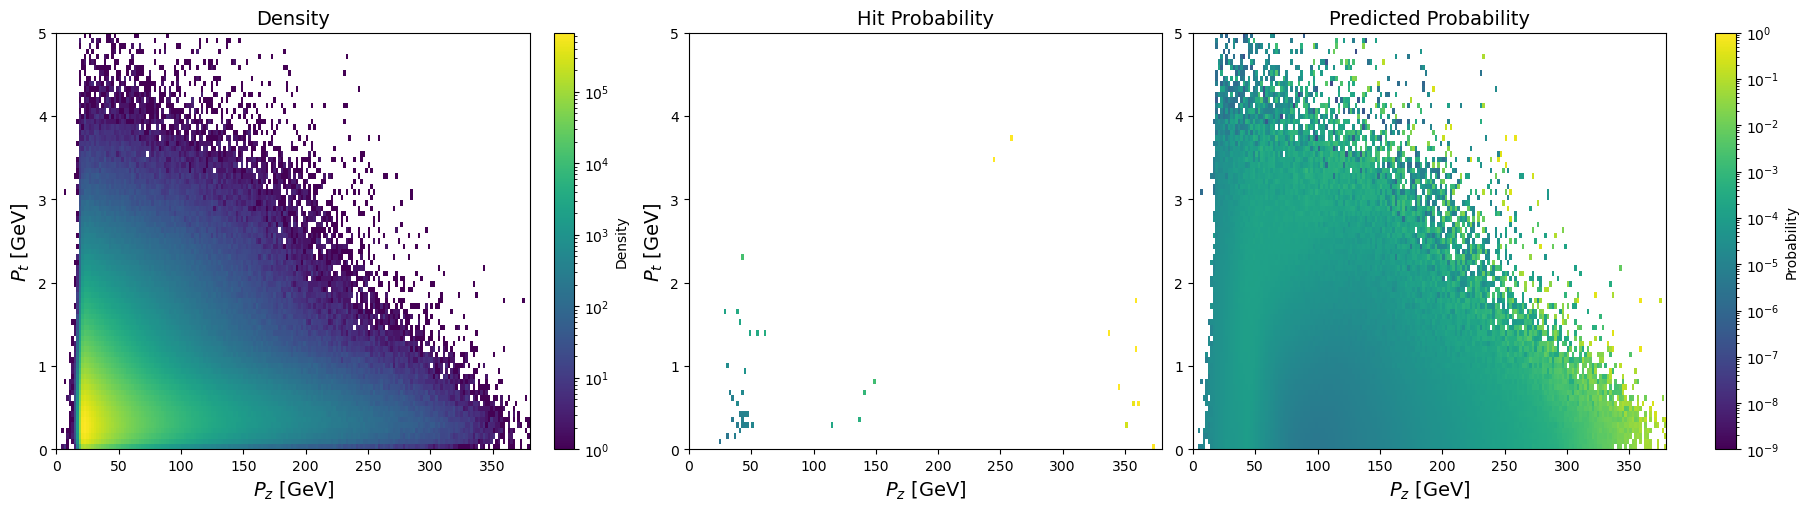

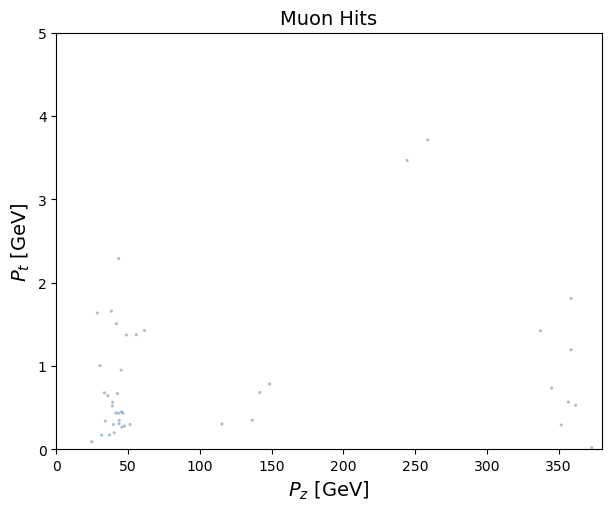

In [16]:
compare_2d_histograms(pz_uniform, pt_uniform, labels_0.flatten(), predictions_uniform)
plt.show()
compare_2d_histograms(pz, pt, hits_test_0, predictions)
plt.show()
plot_hit_scatter(pz, pt, hits_test_0)
plt.show()

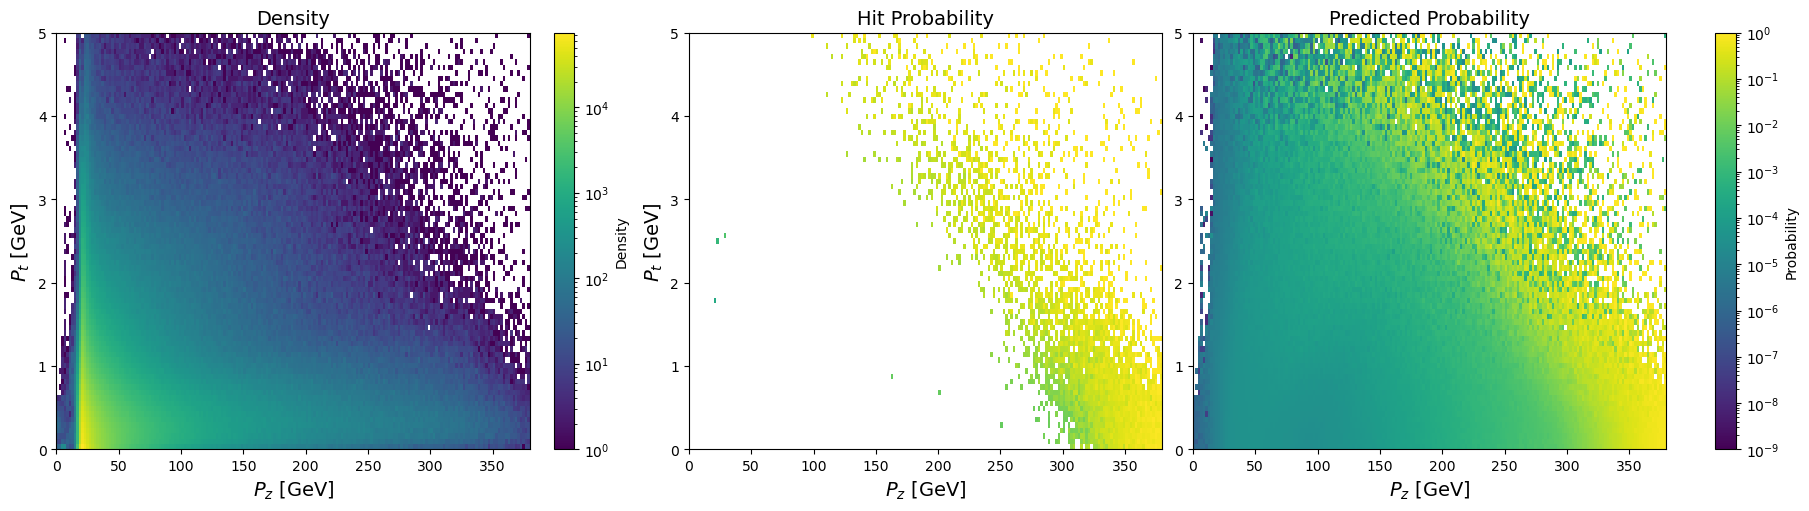

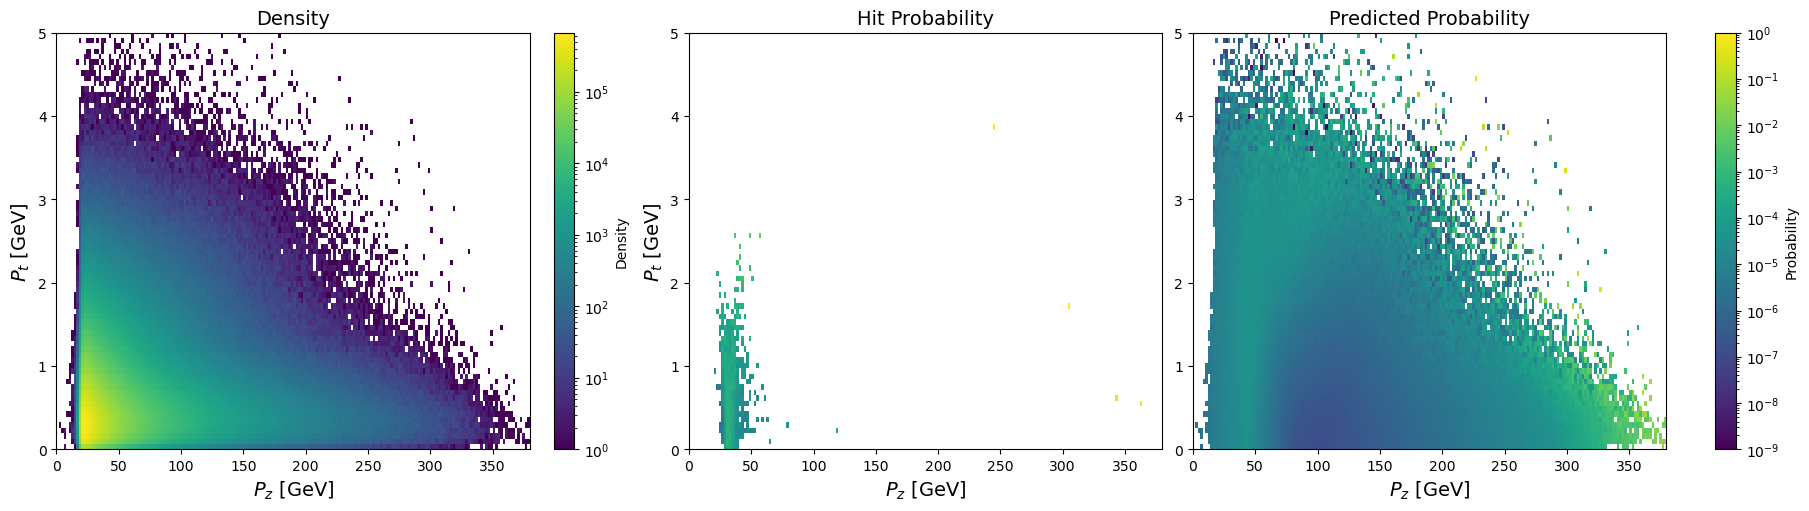

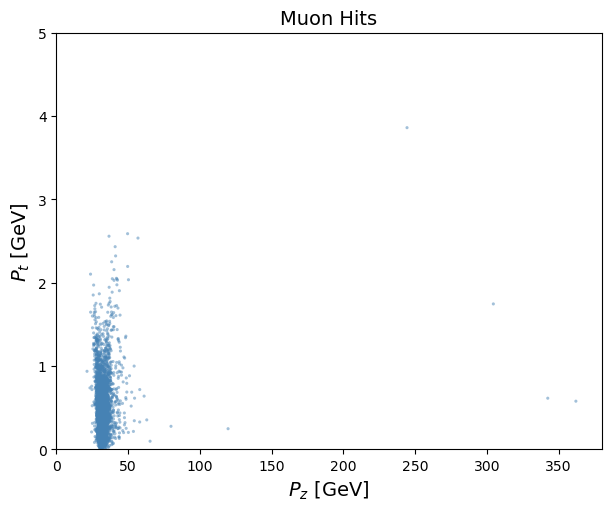

In [17]:
px,py,pz = muons_i[0, :, 0], muons_i[0, :, 1], muons_i[0, :, 2]
pt_uniform = np.sqrt(px**2 + py**2).flatten()
pz_uniform = pz.flatten()

px,py,pz = muons_test_i[0, :, 0], muons_test_i[0, :, 1], muons_test_i[0, :, 2]
pt = np.sqrt(px**2 + py**2).flatten()
pz = pz.flatten()
del px, py

predictions_uniform_i = model_predict_batches(model, phi_i, muons_i).sigmoid().cpu().numpy().flatten()
predictions_test_i = model_predict_batches(model, phi_test_i, muons_test_i).sigmoid().cpu().numpy().flatten()

compare_2d_histograms(pz_uniform, pt_uniform, labels_i.flatten(), predictions_uniform_i)
plt.show()
compare_2d_histograms(pz, pt, hits_test_i, predictions_test_i)
plt.show()
plot_hit_scatter(pz, pt, hits_test_i)
plt.show()


training-sample muons, nominal design
1,999,924 muons in range: sum |dp/du| = 852.5, ||sum dp/du|| = 754.4 -> 88.5% of the per-muon sensitivity survives the sum over muons


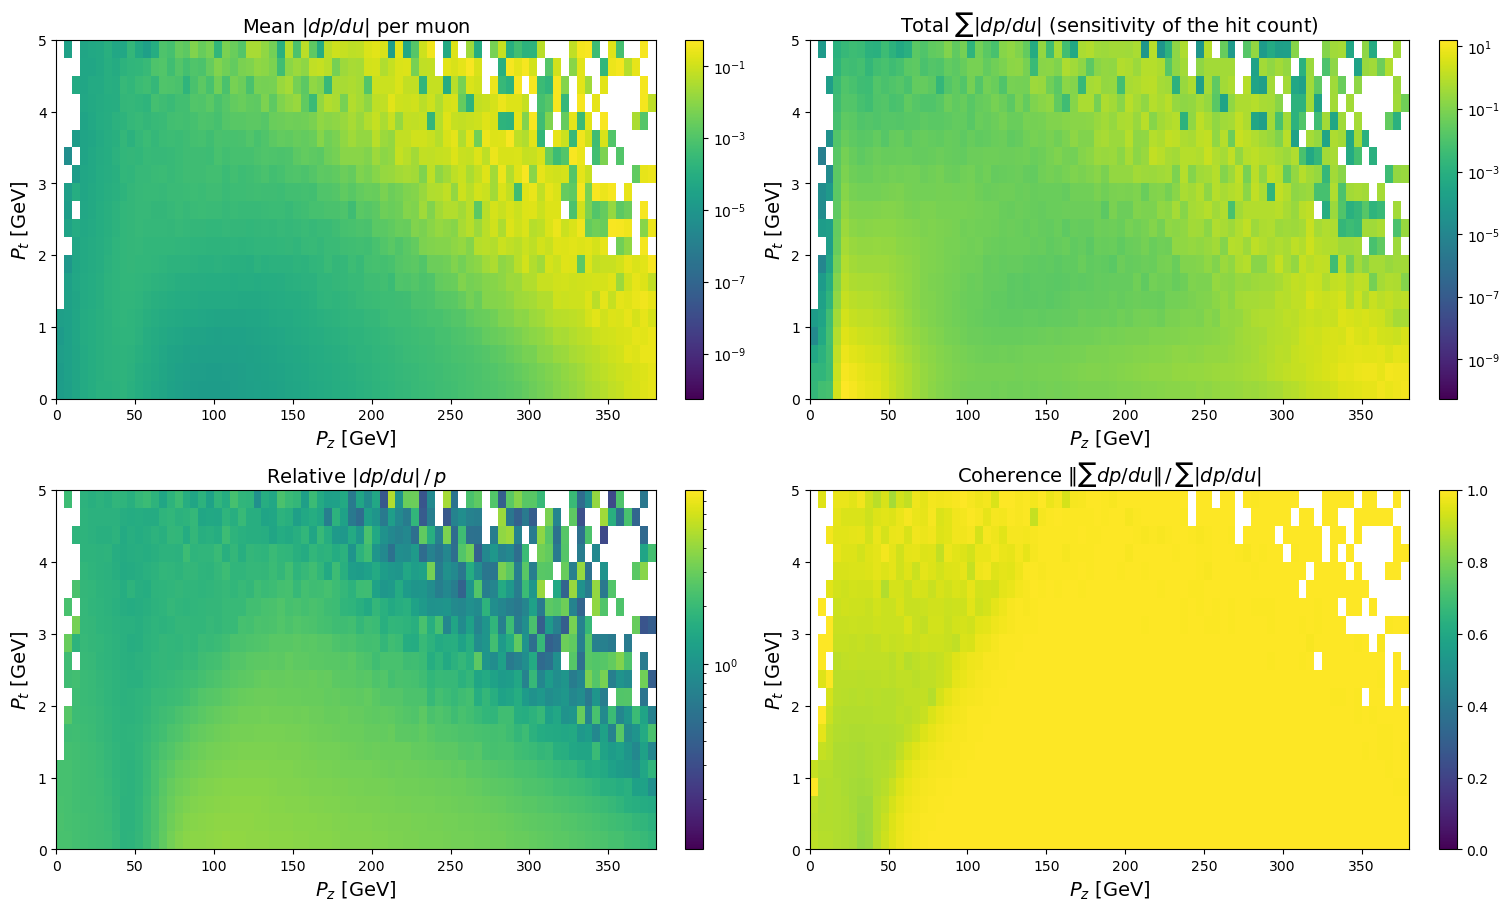

test-sample muons, nominal design
2,000,000 muons in range: sum |dp/du| = 217.5, ||sum dp/du|| = 187.2 -> 86.0% of the per-muon sensitivity survives the sum over muons


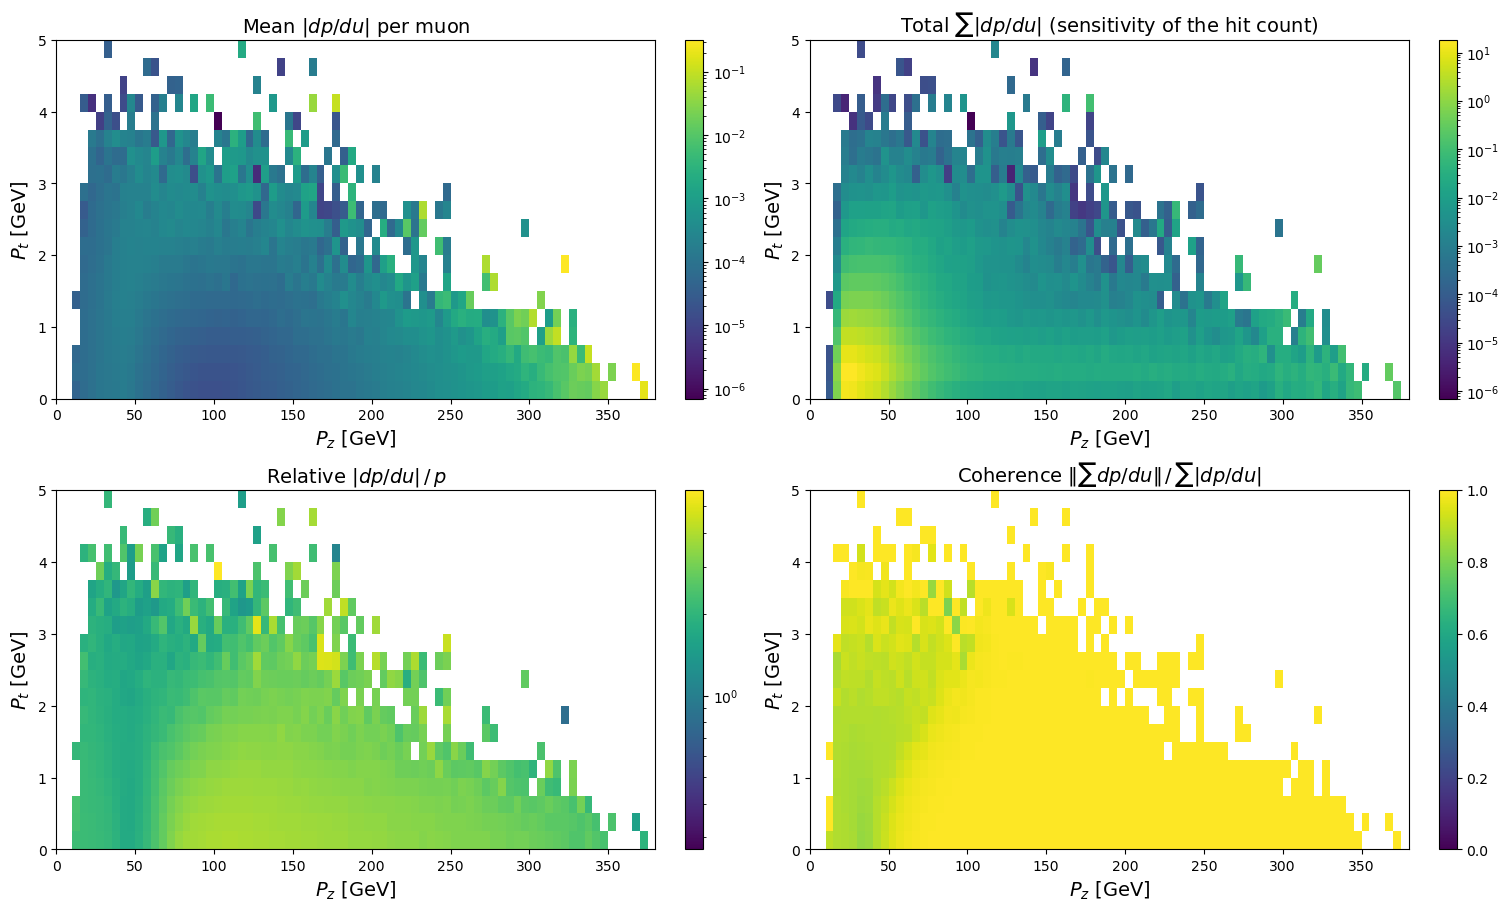

In [18]:
from matplotlib.colors import LogNorm, Normalize

# --- design sensitivity across the (Pz, Pt) plane ------------------------------------
# The logit is z = <b(u), t(x)>, so a single muon's sensitivity to the design is
#     dp/du = p(1-p) J^T t(x),     J = db/du at the design, u = the normalized phi,
# i.e. ONE Jacobian of the branch net (43 inputs, no muons in it) and then a matmul per
# muon -- the identity robustness.py is built on. Everything is accumulated per (Pz, Pt)
# bin as the muons stream by, so the per-muon (n, 43) gradient never has to exist. u is
# the normalized frame: a step of 1 in u_i is a full +-delta move of that parameter.

def gradient_2d_histograms(model, phi, muons, pz_bins=np.linspace(0, 400, 81),
                           pt_bins=np.linspace(0, 13, 53), batch_size=2 ** 18,
                           n_max=2_000_000, device=DEVICE):
    """Four Pz-Pt maps of the per-muon design gradient |dp/du|, at the design `phi`.

    mean |dp/du|   how sensitive a muon of that momentum is to the design
    sum  |dp/du|   the same folded with how many such muons there are: where the
                   sensitivity of the TOTAL hit count is produced
    |dp/du| / p    sensitivity relative to that region's own hit probability
    coherence      ||sum dp/du|| / sum ||dp/du||, in [0, 1]: 1 when every muon of the bin
                   pulls the design the same way, ~0 when they cancel each other out
    """
    m = np.asarray(muons)
    m = m.reshape(-1, m.shape[-1])[:n_max]
    nz, nt = len(pz_bins) - 1, len(pt_bins) - 1
    D = model.dim

    phi_t = torch.as_tensor(np.asarray(phi, dtype=np.float32), device=device).view(-1)
    u = model.normalize_phi(phi_t)
    J = torch.autograd.functional.jacobian(
        lambda uu: model.branch_net(uu.unsqueeze(0)).squeeze(0), u).detach()      # (p, D)
    b = model.branch_net(u.unsqueeze(0)).squeeze(0).detach()                      # (p,)
    ez = torch.as_tensor(np.ascontiguousarray(pz_bins), dtype=torch.float32, device=device)
    et = torch.as_tensor(np.ascontiguousarray(pt_bins), dtype=torch.float32, device=device)

    count = torch.zeros(nz * nt, dtype=torch.float64, device=device)
    psum = torch.zeros(nz * nt, dtype=torch.float64, device=device)
    gabs = torch.zeros(nz * nt, dtype=torch.float64, device=device)
    gvec = torch.zeros(nz * nt, D, dtype=torch.float64, device=device)

    with torch.no_grad():
        for i in range(0, m.shape[0], batch_size):
            x = torch.as_tensor(m[i:i + batch_size, :model.x_dim], dtype=torch.float32,
                                device=device)
            t = model.trunk_net(model.normalize_muons(x))
            pr = torch.sigmoid(t @ b + model.bias)
            g = (pr * (1 - pr)).unsqueeze(1) * (t @ J)                  # (n, D) = dp/du
            iz = torch.bucketize(x[:, 2].contiguous(), ez) - 1
            it = torch.bucketize(x[:, :2].norm(dim=1).contiguous(), et) - 1
            ok = (iz >= 0) & (iz < nz) & (it >= 0) & (it < nt)
            f = (iz[ok] * nt + it[ok])
            count.index_add_(0, f, torch.ones(int(ok.sum()), dtype=torch.float64,
                                              device=device))
            psum.index_add_(0, f, pr[ok].double())
            gabs.index_add_(0, f, g[ok].norm(dim=1).double())
            gvec.index_add_(0, f, g[ok].double())

    count = count.cpu().numpy().reshape(nz, nt)
    psum = psum.cpu().numpy().reshape(nz, nt)
    gabs = gabs.cpu().numpy().reshape(nz, nt)
    gnet = np.linalg.norm(gvec.cpu().numpy(), axis=1).reshape(nz, nt)
    nz_mask = count > 0
    mean_g = np.divide(gabs, count, out=np.zeros_like(gabs), where=nz_mask)
    mean_p = np.divide(psum, count, out=np.zeros_like(psum), where=nz_mask)
    rel_g = np.divide(mean_g, mean_p, out=np.zeros_like(mean_g), where=mean_p > 0)
    coh = np.divide(gnet, gabs, out=np.zeros_like(gabs), where=gabs > 0)

    print(f'{int(count.sum()):,} muons in range: sum |dp/du| = {gabs.sum():.4g}, '
          f'||sum dp/du|| = {np.linalg.norm(gvec.sum(0).cpu().numpy()):.4g} '
          f'-> {np.linalg.norm(gvec.sum(0).cpu().numpy()) / max(gabs.sum(), 1e-30):.1%} '
          f'of the per-muon sensitivity survives the sum over muons')

    cmap = plt.cm.viridis.copy()
    cmap.set_bad('white')
    panels = [
        (mean_g, nz_mask, 'Mean $|dp/du|$ per muon', True),
        (gabs, nz_mask, 'Total $\\sum |dp/du|$ (sensitivity of the hit count)', True),
        (rel_g, mean_p > 0, 'Relative $|dp/du| \\, / \\, p$', True),
        (coh, gabs > 0, 'Coherence $\\|\\sum dp/du\\| \\, / \\, \\sum |dp/du|$', False),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)
    for ax, (M, mask, title, log) in zip(axes.ravel(), panels):
        pos = M[mask & (M > 0)]
        if log:
            norm = LogNorm(vmin=pos.min(), vmax=pos.max()) if pos.size else None
        else:
            norm = Normalize(vmin=0, vmax=1)
        im = ax.pcolormesh(pz_bins, pt_bins, np.ma.masked_where(~mask, M).T, cmap=cmap,
                           norm=norm)
        ax.set_xlim(0, 380)
        ax.set_ylim(0, 5)
        ax.set_xlabel('$P_z$ [GeV]', fontsize=14)
        ax.set_ylabel('$P_t$ [GeV]', fontsize=14)
        ax.set_title(title, fontsize=14)
        fig.colorbar(im, ax=ax)
    return fig, axes


print('training-sample muons, nominal design')
gradient_2d_histograms(model, phi_0, muons_0)
plt.show()
print('test-sample muons, nominal design')
gradient_2d_histograms(model, phi_test_0, muons_test_0)
plt.show()

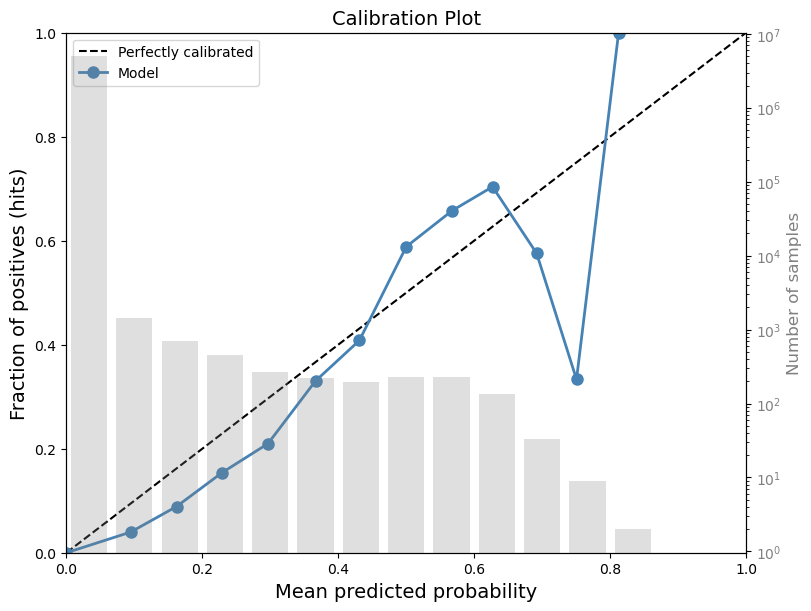

In [19]:
plot_calibration(predictions_uniform, labels_0, n_bins=15)
plt.show()

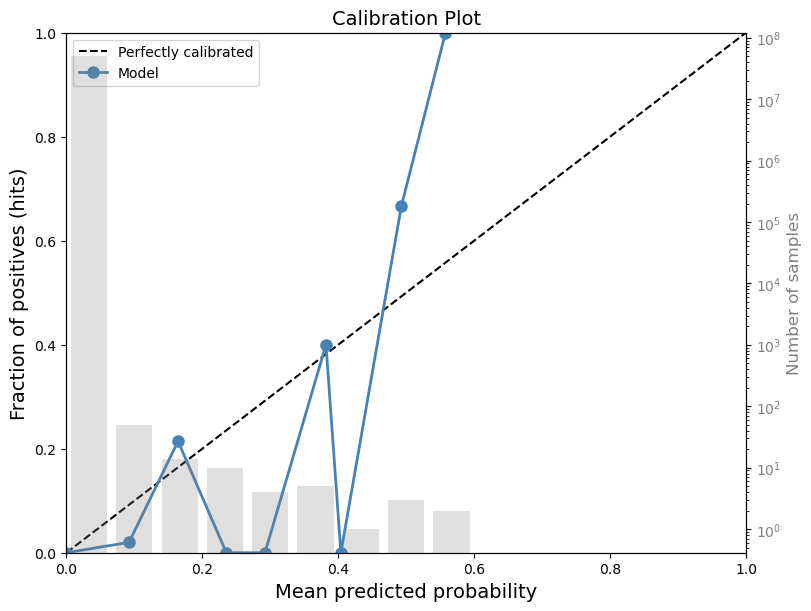

In [20]:
plot_calibration(predictions, hits_test_0, n_bins=15)
plt.show()

In [21]:
print(f"Total number of HITS (uniform): {labels_0.sum():.2f}")
print(f"Predicted number of HITS (uniform): {predictions_uniform.sum():.2f} ± {np.sqrt(np.sum(predictions_uniform * (1 - predictions_uniform))):.2f}")
print(f"Error: {abs(labels_0.sum() - predictions_uniform.sum()):.2f} ({abs(labels_0.sum() - predictions_uniform.sum())/labels_0.sum()*100:.2f}%)")

Total number of HITS (uniform): 841.00
Predicted number of HITS (uniform): 1455.02 ± 33.11
Error: 614.02 (73.01%)


In [22]:
print(f"Total number of HITS (real sample): {hits_test_0.sum():.2f}")
print(f"Predicted number of HITS (real sample): {predictions.sum():.2f} ± {np.sqrt(np.sum(predictions * (1 - predictions))):.2f}")
print(f"Error: {abs(hits_test_0.sum() - predictions.sum()):.2f} ({abs(hits_test_0.sum() - predictions.sum())/hits_test_0.sum()*100:.2f}%)")

Total number of HITS (real sample): 44.00
Predicted number of HITS (real sample): 2694.13 ± 51.86
Error: 2650.13 (6023.03%)


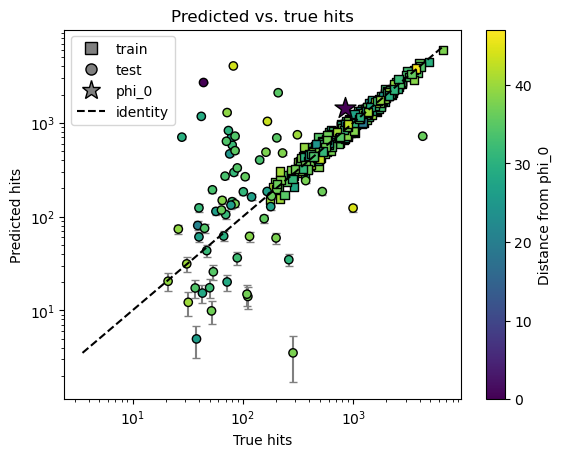

In [23]:
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

PRED_BATCH_SIZE = 2**18

# --- training points: index 0 is phi_0 (already computed above), rest from phis_training ---
hits_train = [labels_0.sum()]
preds_train = [predictions_uniform.sum()]
stds_train = [np.sqrt(np.sum(predictions_uniform * (1 - predictions_uniform)))]
dists_train = [0.0]

with torch.no_grad():
    for i in range(1, phis_training.shape[0]):
        phi_raw_i = phis_training[i]
        hits_train.append(hits_training[i].sum())
        phi_t = torch.from_numpy(phis_training[i].astype(np.float32)).to(DEVICE)
        muons_t = torch.from_numpy(muons_training[i].astype(np.float32)).to(DEVICE)
        pred, std = model.predict_hits(phi_t, muons_t, batch_size=PRED_BATCH_SIZE)
        preds_train.append(pred.item())
        stds_train.append(std.item())
        dists_train.append(np.linalg.norm(phi_raw_i - phi_0))



# --- test points: from the held-out "real sample" phis/muons/labels/predictions ---
hits_test_ = [hits_test_0.sum()]
preds_test = [predictions.sum()]
stds_test = [np.sqrt(np.sum(predictions * (1 - predictions)))]
dists_test = [np.linalg.norm(phi_test_0 - phi_0)]

with torch.no_grad():
    for i in range(1, phis_test.shape[0]):
        hits_test_.append(hits_test[i].sum())
        phi_raw_i = phis_test[i]
        phi_t = torch.from_numpy(phi_raw_i.astype(np.float32)).to(DEVICE)
        muons_t = torch.from_numpy(muons_test[i].astype(np.float32)).to(DEVICE)
        pred, std = model.predict_hits(phi_t, muons_t, batch_size=PRED_BATCH_SIZE)
        preds_test.append(pred.item())
        stds_test.append(std.item())
        dists_test.append(np.linalg.norm(phi_raw_i - phi_0))

dists_all = dists_train + dists_test
norm = Normalize(vmin=min(dists_all), vmax=max(dists_all))
cmap = plt.cm.viridis

fig, ax = plt.subplots()

ax.errorbar(hits_train[1:], preds_train[1:], yerr=stds_train[1:], fmt='none',
            ecolor='gray', capsize=3, zorder=1)
ax.errorbar(hits_test_, preds_test, yerr=stds_test, fmt='none',
            ecolor='gray', capsize=3, zorder=1)
ax.errorbar(hits_train[0], preds_train[0], yerr=stds_train[0], fmt='none',
            ecolor='gray', capsize=3, zorder=1)

ax.scatter(hits_train[1:], preds_train[1:], c=dists_train[1:], cmap=cmap, norm=norm,
           marker='s', edgecolors='k', zorder=2)
ax.scatter(hits_test_, preds_test, c=dists_test, cmap=cmap, norm=norm,
           marker='o', edgecolors='k', zorder=2)
ax.scatter(hits_train[0], preds_train[0], c=[dists_train[0]], cmap=cmap, norm=norm,
           marker='*', s=250, edgecolors='k', zorder=2)

lims = [min(hits_train + preds_train + hits_test_ + preds_test),
        max(hits_train + preds_train + hits_test_ + preds_test)]
ax.plot(lims, lims, 'k--')

legend_elements = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markeredgecolor='k', markersize=8, label='train'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markeredgecolor='k', markersize=8, label='test'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='gray', markeredgecolor='k', markersize=14, label='phi_0'),
    Line2D([0], [0], color='k', linestyle='--', label='identity'),
]
ax.legend(handles=legend_elements)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='Distance from phi_0')

ax.set_xlabel('True hits')
ax.set_ylabel('Predicted hits')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Predicted vs. true hits')
plt.show()
